In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from data import Data

obj = Data()
df = obj.get_data()
clean_data = obj.get_clean_data()

In [2]:
clean_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [3]:
clean_data.info()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  str           
 1   StockCode    397884 non-null  str           
 2   Description  397884 non-null  str           
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
 8   Revenue      397884 non-null  float64       
 9   Month        397884 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), str(5)
memory usage: 33.4 MB


In [4]:
top_country = clean_data.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

In [5]:
top_country.index

Index(['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France',
       'Australia', 'Spain', 'Switzerland', 'Belgium', 'Sweden'],
      dtype='str', name='Country')

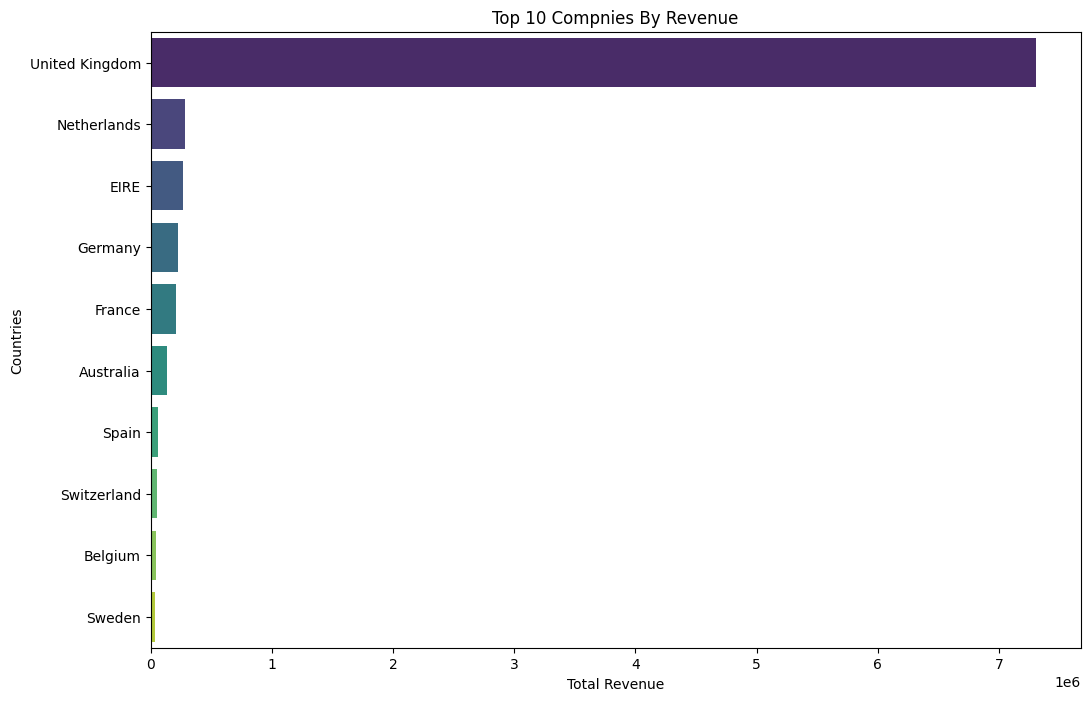

In [6]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_country.values , y=top_country.index, hue=top_country.index ,palette='viridis')
plt.title("Top 10 Compnies By Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Countries")
plt.show()

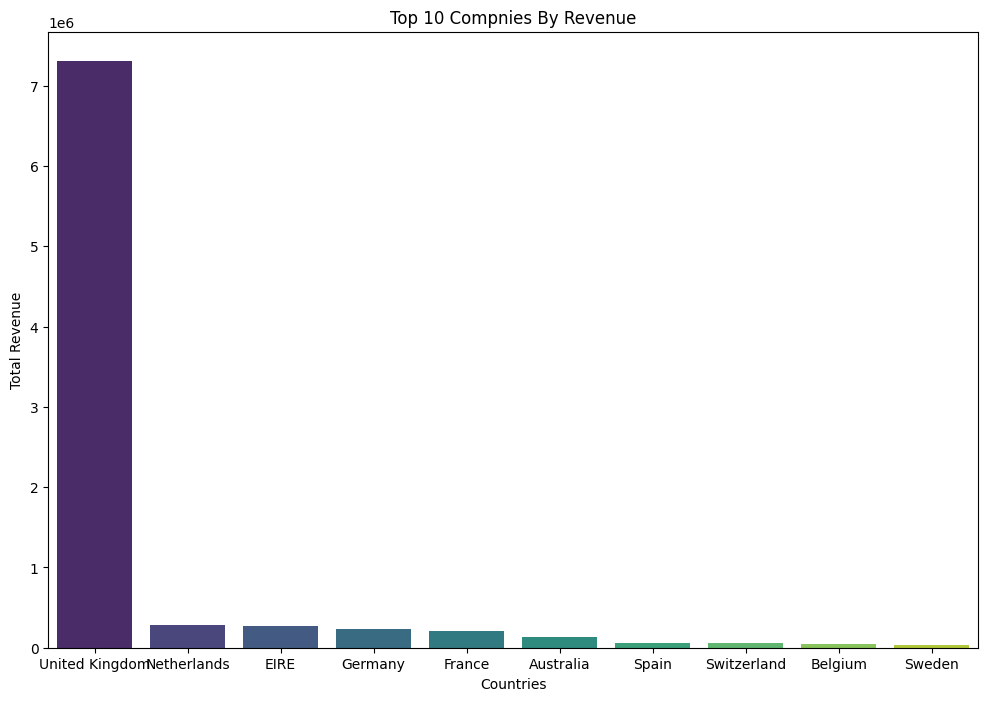

In [7]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_country.index , y=top_country.values, hue=top_country.index ,palette='viridis')
plt.title("Top 10 Compnies By Revenue")
plt.xlabel("Countries")
plt.ylabel("Total Revenue")
plt.show()

In [8]:
df_sample = clean_data.sample(1000 , random_state=1)

In [9]:
df_sample['Country'].value_counts().index

Index(['United Kingdom', 'Germany', 'EIRE', 'France', 'Netherlands', 'Belgium',
       'Spain', 'Switzerland', 'Portugal', 'Norway', 'Finland', 'Australia',
       'Channel Islands', 'Sweden', 'RSA', 'Canada', 'Italy', 'Singapore',
       'Japan', 'Austria'],
      dtype='str', name='Country')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'Germany'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Netherlands'),
  Text(5, 0, 'Belgium'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Portugal'),
  Text(9, 0, 'Norway'),
  Text(10, 0, 'Finland'),
  Text(11, 0, 'Australia'),
  Text(12, 0, 'Channel Islands'),
  Text(13, 0, 'Sweden'),
  Text(14, 0, 'RSA'),
  Text(15, 0, 'Canada'),
  Text(16, 0, 'Italy'),
  Text(17, 0, 'Singapore'),
  Text(18, 0, 'Japan'),
  Text(19, 0, 'Austria')])

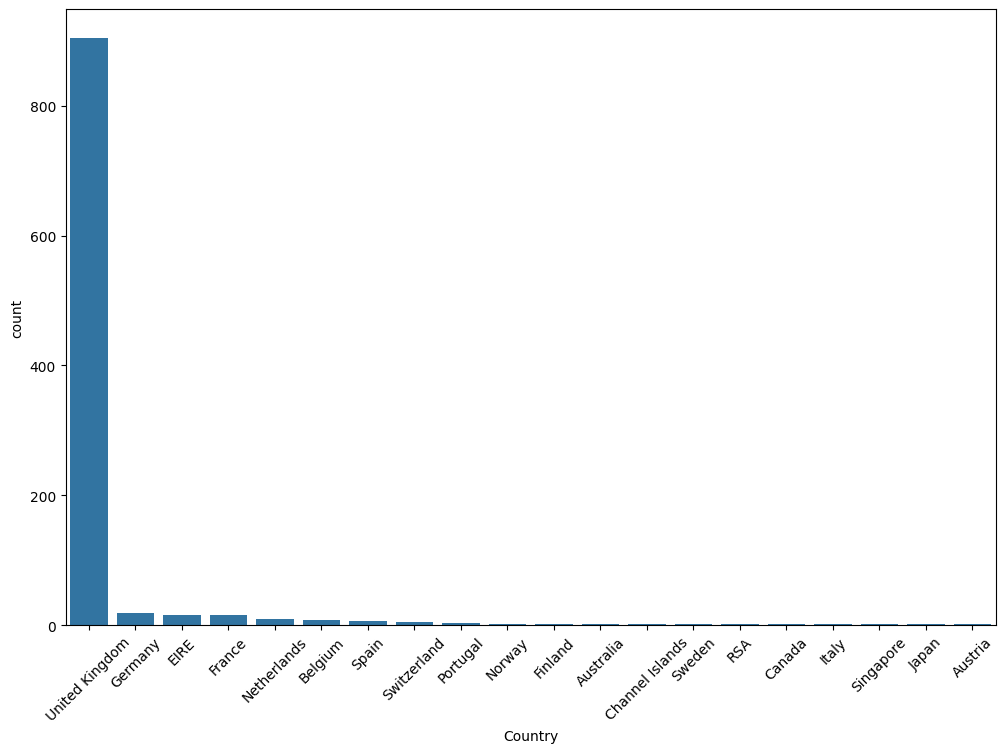

In [10]:
plt.figure(figsize=(12,8))
sns.countplot(data = df_sample , x='Country' , order=df_sample['Country'].value_counts().index)
plt.xticks(rotation=45)

In [11]:
top_country = clean_data["Country"].value_counts().head(5).index.tolist()
top_country

['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain']

In [12]:
df_top = clean_data[clean_data["Country"].isin(top_country)].copy()
grouped = df_top.groupby(["Country","Month"])["Revenue"].sum().reset_index()
grouped.head()

,Country,Month,Revenue
0,EIRE,2010-12,8813.88
1,EIRE,2011-01,21904.19
2,EIRE,2011-02,10126.52
3,EIRE,2011-03,21674.36
4,EIRE,2011-04,7570.50


In [13]:
grouped["Month"] = pd.to_datetime(grouped["Month"])
grouped = grouped.sort_values('Month')
grouped['Month'] = grouped["Month"].dt.strftime('%Y-%m')

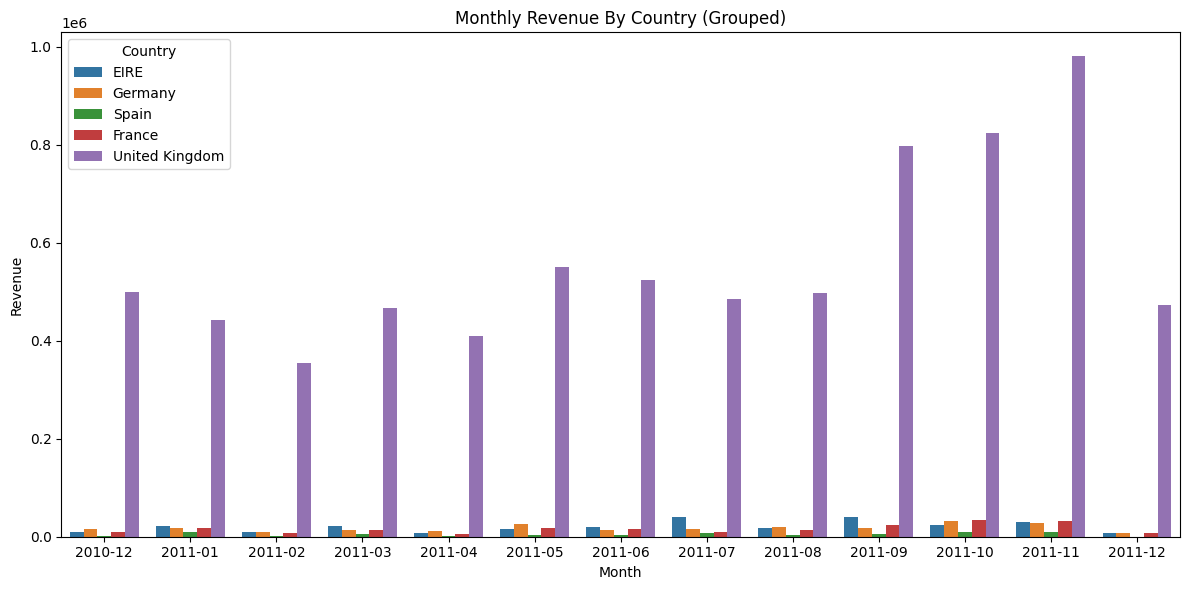

In [14]:
# Grouped BarPlot Using Seaborn

plt.figure(figsize=(12,6))
sns.barplot(data=grouped , x='Month' , y="Revenue" , hue="Country")
plt.title('Monthly Revenue By Country (Grouped)')
plt.xlabel('Month')
plt.ylabel("Revenue")
plt.tight_layout()
plt.legend(title="Country")
plt.show()